# Jupyter 中使用中文 Matplotlib 测试

In [1]:
%load_ext autoreload
%autoreload 2

from matplotlib import pyplot as plt
from mksci_font import mksci_font, show, config_font, update_font

字体 SunTimes 的合成来自于[这里](https://www.jianshu.com/p/4ad9b287535f)
合成软件是 [FontForge](https://formulae.brew.sh/formula/fontforge)

## 单个函数修改

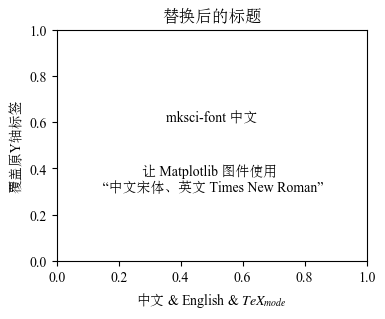

In [2]:
msg = "让 Matplotlib 图件使用 \n “中文宋体、英文 Times New Roman”"
mapping_string = {"Origin title": "替换后的标题"}


@mksci_font(mapping_string, ylabel="覆盖原Y轴标签")
def plot():
    _, ax = plt.subplots(figsize=(4, 3))
    ax.text(0.5, 0.6, "mksci-font 中文", ha="center")
    ax.text(0.5, 0.3, msg, ha="center")
    ax.set_ylabel("will be replaced...")  # will be replaced by '中文'
    ax.set_xlabel("中文 & English & $TeX_{mode}$")
    ax.set_title("Origin title")
    return ax


ax = plot()
show()

## 更新已经生成的图片

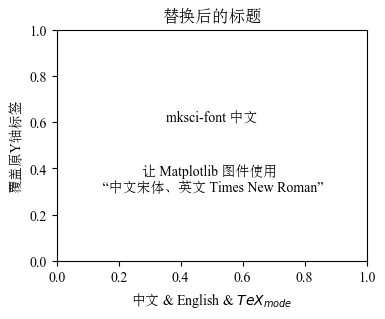

In [3]:
_, ax = plt.subplots(figsize=(4, 3))
ax.text(0.5, 0.6, "mksci-font 中文", ha="center")
ax.text(0.5, 0.3, msg, ha="center")
ax.set_ylabel("will be replaced...")  # will be replaced by '中文'
ax.set_xlabel("中文 & English & $TeX_{mode}$")
ax.set_title("Origin title")

# 更新已经生成的图件
msg = "让 Matplotlib 图件使用 \n “中文宋体、英文 Times New Roman”"
mapping_string = {"Origin title": "替换后的标题"}
update_font(ax, mapping_string, ylabel="覆盖原Y轴标签")
show();

## 更复杂的一个例子

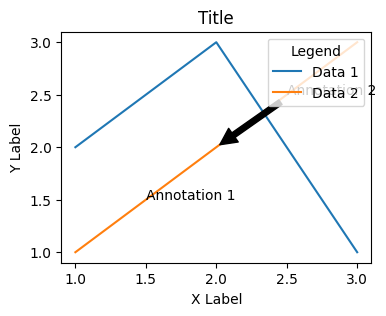

In [4]:
import matplotlib.pyplot as plt

# Create a simple figure with labels, title, and annotations
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot([1, 2, 3], [2, 3, 1], label="Data 1")
ax.plot([1, 2, 3], [1, 2, 3], label="Data 2")
ax.set_xlabel("X Label")
ax.set_ylabel("Y Label")
ax.set_title("Title")
ax.text(1.5, 1.5, "Annotation 1")
ax.annotate(
    "Annotation 2",
    xy=(2, 2),
    xytext=(2.5, 2.5),
    arrowprops=dict(facecolor="black", shrink=0.05),
)
ax.legend(title="Legend", loc=1)
plt.show();

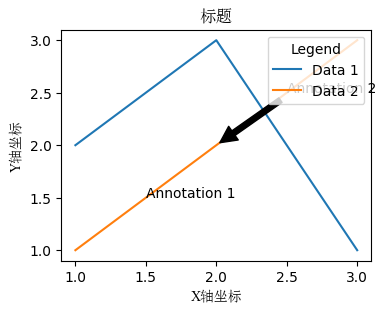

In [5]:
from mksci_font.font_wrapper import update_font

# refresh = False, 仅将指定元素替换为中文
updated_ax = update_font(
    ax, refresh=False, xlabel="X轴坐标", ylabel="Y轴坐标", title="标题"
)
updated_ax.figure

## 修改其它元素

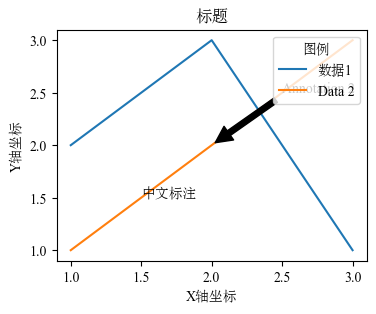

In [6]:
mapping = {"Annotation 1": "中文标注", "Data 1": "数据1", "Legend": "图例"}

# refresh = True, 将更新字体将作用于所有的文本对象
new_ax = update_font(updated_ax, mapping_strings=mapping, refresh=True)
new_ax.figure

## 修改配置

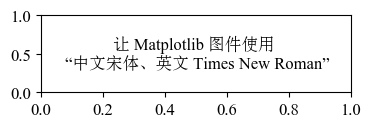

In [7]:
# 推荐写法：显式传 rc_params，旧写法仍兼容
config_font(rc_params={"font.size": 12})

_, ax = plt.subplots(figsize=(4, 1))
ax.text(0.5, 0.5, msg, ha="center", va="center")
plt.show();